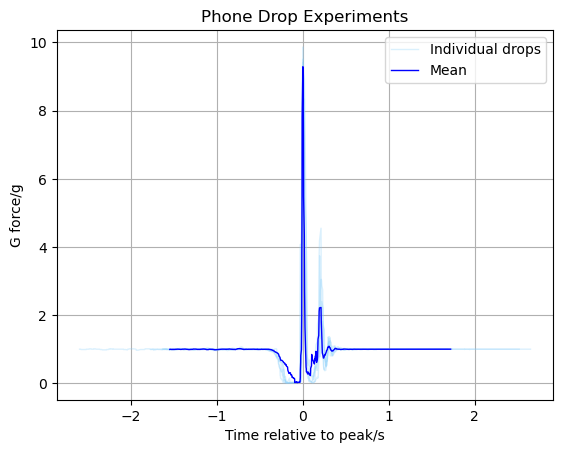

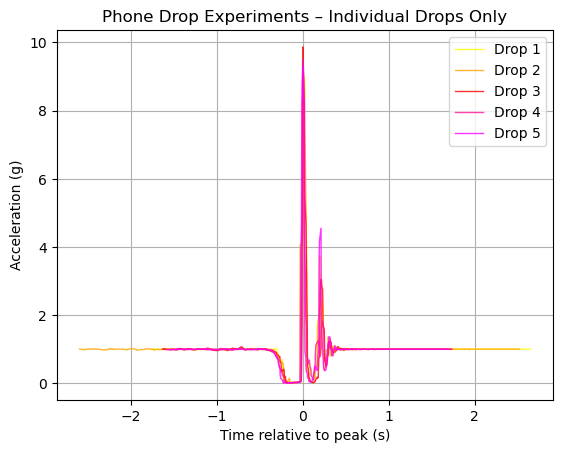

FileNotFoundError: [Errno 2] No such file or directory: 'plots/individual_drops.png'

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt # matplotlib is plotting library, helps create graph
import numpy as np # imports numpy for arrays and numbers
from scipy.signal import find_peaks
files = [
    '2phonedrop.csv',
    '1phonedrop.csv',
    '3phonedrop.csv',
    '4phonedrop.csv',
    '5phonedrop.csv'
] #list of files

includedData = 400  # data points to include
A_all = [] #empty list to store data for A later
t_all = []
first = True # creating first variable and setting to true, helps to only label first line in group later

for file in files: # loop to process .csv files
    phonedata = np.loadtxt(file, skiprows=2, delimiter=',') # loading data into a numerical array from .csv files
    t = phonedata[:,0]
    A = phonedata[:,4] # taking the 1st column for time and 5th for total acceleration
    
    peaks, properties = find_peaks(A, prominence = 5)
    peak_index = peaks[np.argmax(A[peaks])] #finds max value for each set of A data, sets it as peak index
    start = peak_index - includedData
    end = peak_index + includedData # including 400 points before and after peak (so arrays are equal sizes)

    t_cut = t[start:end]
    A_cut = A[start:end] 
    t_shifted = t_cut - t[peak_index] # adjusting so peak is at t=0

    A_all.append(A_cut) # adds the acceleration data to list to average later
    t_all.append(t_shifted)
    if first:
        plt.plot(t_shifted, A_cut, 'lightskyblue', linewidth=1, label='Individual drops', alpha = 0.3) 
        first = False # changes variable so no longer first loop iteration
    else:
        plt.plot(t_shifted, A_cut, 'lightskyblue', linewidth=1, alpha = 0.3) 
        #same but without the label, this ensures only one "individual drops" label 

A_all = np.array(A_all) # converting list to an array
A_mean = np.mean(A_all, axis=0) # calculating mean at each time point, axis=0 so across all data sets

plt.plot(t_shifted, A_mean, 'blue', linewidth=1, label='Mean') # plotting mean, same command as earlier

plt.xlabel('Time relative to peak/s')
plt.ylabel('G force/g')
plt.title('Phone Drop Experiments') # x labels, y labels and title
plt.grid(True) # adds grid 
plt.legend() # adds a legend
plt.show() # shows legend


plt.figure()
colours = ['yellow', 'orange', 'red', 'deeppink', 'magenta']

for i, A_cut in enumerate(A_all):
    t_shifted = t_all[i]
    plt.plot(t_shifted, A_cut,
             color=colours[i % len(colours)],   # cycle through colours
             linewidth=1, alpha=0.8, label=f'Drop {i+1}')


plt.xlabel('Time relative to peak (s)')
plt.ylabel('Acceleration (g)')
plt.title('Phone Drop Experiments – Individual Drops Only')
plt.grid(True)
plt.legend()
plt.show()

mask = (t_all[0] >= -0.5) & (t_all[0] <= 0)# selecting window for table, estimate based on looking at graph
t_window = t_all[0][mask]
A_window = A_mean[mask] # sections of arrays
table = np.column_stack((t_window, A_window)) # creating a table to visually checks where initial drop starts and ends
#print(table)
t = t_all[0]
A = A_mean # taking mean values for A and t values across all data
g = 1.0 

freefall_mask= (t >= -0.30) & (t<=-0.02) #drop range
t_slice = t[freefall_mask]
A_slice = A_mean[freefall_mask]
area = np.trapz(A_slice, t_slice) # integrating to find velocity
print("area under curve =", area) 
dv = area*9.81 # in m/s 
impact_velocity = abs(dv) #absolute value bc phone sensor treats velocity down as negative
print("impact velocity is", impact_velocity, " m/s") 

h = 0.4 #measured drop height
g_metres = 9.81 #g in m/s^2
tolerance = 0.1 #allowable variation from theoretical value
theoretical_velocity = np.sqrt(2*h*g_metres)

difference = abs(impact_velocity - theoretical_velocity)
if difference <= tolerance:
    print("Impact velocity (", impact_velocity,") is within allowable range of theoretical velocity (", theoretical_velocity,") .")
else:
    print("Impact velocity (", impact_velocity,") is outside of allowable range of theoretical velocity (", theoretical_velocity,"), data must be re-examined")
    #checks data


print("mean g during fall should be 0, instead is", np.mean(A_mean[(t >= -0.30) & (t <= -0.02)])) 
#mean acceleration within given range, should be 0 (no contact forces on phone). 
#Used to identify sensor bias to determine if this is causing data to be different from theoretical value
freefall_mask = (t >= -0.30) & (t <= -0.02)
A_offset = np.mean(A_mean[freefall_mask]) 
A_corrected = A_mean - A_offset #correcting sensor error
A_net = A_corrected - g # removing base level from being still
mask = (t >= -0.350) & (t <=-0.072) #range of values when phone was falling
t_slice = t[mask]
A_slice = A_net[mask]
area = np.trapz(A_slice, t_slice) # integrating to find velocity
print("area under curve =", area) 
dv = area*9.81 # in m/s 
corrected_impact_velocity = abs(dv) # absolute value as phone sensor treats velocity down as negative
difference = abs(corrected_impact_velocity - theoretical_velocity)
if difference <= tolerance:
    print("After correcting sensor bias, impact velocity (", corrected_impact_velocity,") is within allowable range of theoretical velocity (", theoretical_velocity,") .")
else:
    print("After correcting sensor bias, impact velocity  (", corrected_impact_velocity,") is still outside of allowable range of theoretical velocity (", theoretical_velocity,"), data must be re-examined")
